# 22 — CNN Raster Encoder (Track B — No Quadtree)

**Goal:** Train a CNN encoder directly on rasterized polygon images.
No quadtree encoding needed — any WKT polygon can be rasterized in milliseconds.

**Training data:** Parks 50k + Sports 50k (mixed, WJ GT pairs)

**Zero-shot eval:** Google Maps 20k — model has never seen this dataset

**Pipeline:**
- Input: 64×64 binary raster (polygon shape)
- CNN encoder → 512-D simplex embedding (same space as nb 16)
- Loss: intersection triplet (same as nb 16, but on pixel space)
- Stage-1 search: intersection (Σmin) on 512-D embeddings
- Stage-2 rerank parks: exact WJ on original quadtree vectors
- Stage-2 rerank sports: pixel IoU on rasters (fully quadtree-free)
- Zero-shot Google: stage-1 intersection only (no GT → qualitative only)

**Prereqs:** Run `20_cache_raster.py` first

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
run_training = True
run_eval     = True
device_str   = "cuda:0"

PARKS_QUERY_START  = 40000
SPORTS_QUERY_START = 40000

GRID_SIZE    = 64
OUT_DIM      = 512
max_pos      = 30
batch_size   = 2048   # 4 GPUs × 512 — more InfoNCE negatives per step
epochs       = 50
lr           = 1e-3
weight_decay = 1e-4
temperature  = 0.07

gpu_ids      = [0, 1, 2, 3]   # DataParallel across 4 A100s

candidate_ks        = [500, 1000]
rerank_batch_size   = 32
search_corpus_chunk = 4000

ckpt_path = "/tmp/best_cnn_raster.pt"
out_path  = "/tmp/results_cnn_raster.pkl"
seed      = 42

In [3]:
import gc
import pickle
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

device = torch.device(device_str if torch.cuda.is_available() else "cpu")
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print(f"device={device} | grid={GRID_SIZE}x{GRID_SIZE} | out_dim={OUT_DIM}")

device=cuda:0 | grid=64x64 | out_dim=512


In [4]:
# ── CNN Encoder + InfoNCE loss ────────────────────────────────────────────────
class RasterCNNEncoder(nn.Module):
    """
    CNN encoder: 64x64 binary raster → 512-D simplex embedding.
    Same simplex output as nb 16 — stage-1 uses intersection (Σmin).
    Input is dataset-agnostic: any WKT polygon → rasterize → embed.
    """
    def __init__(self, grid_size=64, out_dim=512):
        super().__init__()
        feat_dim = 128 * (grid_size // 8) ** 2  # after 3 MaxPool(2)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 32x32
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 16x16
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 8x8
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, out_dim, bias=False),
            nn.BatchNorm1d(out_dim),
        )

    def forward(self, x):
        out = self.encoder(x)
        out = self.head(out)
        out = F.relu(out)
        out = out / out.sum(dim=1, keepdim=True).clamp(min=1e-10)
        return out


def intersection(a, b):
    return torch.minimum(a, b).sum(dim=-1)


def infonce_loss(anchors, positives, temperature=0.07):
    """
    InfoNCE (NT-Xent) loss using intersection (Σmin) as similarity.
    Replaces triplet hard-negative loss — avoids mode collapse when
    all polygons in a batch look similar (parks/sports within-class batches).

    Loss = -log( exp(I(a_i, p_i)/τ) / Σ_j exp(I(a_i, p_j)/τ) )
    Symmetric: average of anchor→positive and positive→anchor directions.
    """
    B   = anchors.shape[0]
    # (B, B) pairwise intersections
    sim = torch.min(anchors.unsqueeze(1), positives.unsqueeze(0)).sum(dim=2)
    sim = sim / temperature
    labels = torch.arange(B, device=anchors.device)
    # Symmetric loss (both directions)
    loss = (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels)) / 2

    with torch.no_grad():
        i_pos = sim.diagonal().mean() * temperature
        mask  = ~torch.eye(B, dtype=torch.bool, device=anchors.device)
        i_neg = (sim * temperature)[mask].mean()

    return loss, i_pos.item(), i_neg.item()


print(f"RasterCNNEncoder: 64x64 → {128*(GRID_SIZE//8)**2} → {OUT_DIM}-D simplex | loss=InfoNCE τ={temperature}")

RasterCNNEncoder: 64x64 → 8192 → 512-D simplex | loss=InfoNCE τ=0.07


In [5]:
# ── Load cached rasters and GT ───────────────────────────────────────────────
print("Loading rasters...")
parks_rasters  = np.load("/tmp/rasters_parks_50k.npy")   # (50000, 64, 64) float32
sports_rasters = np.load("/tmp/rasters_sports_50k.npy")  # (50000, 64, 64) float32
lakes_rasters  = np.load("/tmp/rasters_lakes_20k.npy")   # (20000, 64, 64) float32 — zero-shot
print(f"parks={parks_rasters.shape} sports={sports_rasters.shape} lakes={lakes_rasters.shape}")
print(f"parks avg_coverage={parks_rasters.sum((1,2)).mean():.2f} | "
      f"sports={sports_rasters.sum((1,2)).mean():.2f} | "
      f"lakes={lakes_rasters.sum((1,2)).mean():.2f}")

print("Loading GT...")
with open("/tmp/gt_lookup_parks_50k.pkl", "rb") as f:
    parks_gt  = pickle.load(f)
with open("/tmp/gt_lookup_sports_50k.pkl", "rb") as f:
    sports_gt = pickle.load(f)
print(f"Parks GT: {len(parks_gt)} queries | Sports GT: {len(sports_gt)} queries")

print("Loading parks quadtree for WJ rerank...")
qt_parks      = np.load("/tmp/qt_parks_50k.npy")
corpus_qt     = qt_parks[:PARKS_QUERY_START]
corpus_sums   = corpus_qt.sum(axis=1)
query_qt      = qt_parks[PARKS_QUERY_START:]
print(f"qt_parks={qt_parks.shape}")

Loading rasters...
parks=(50000, 64, 64) sports=(50000, 64, 64) lakes=(20000, 64, 64)
parks avg_coverage=1045.18 | sports=1459.49 | lakes=1018.45
Loading GT...
Parks GT: 10000 queries | Sports GT: 10000 queries
Loading parks quadtree for WJ rerank...
qt_parks=(50000, 18382)


In [6]:
# ── Training Dataset — Parks + Sports mixed ───────────────────────────────────
class RasterPairDataset(Dataset):
    """
    Anchor-positive pairs drawn from parks GT + sports GT.
    Google rasters are NOT used for training — held out for zero-shot eval.
    Rasters are float32 in [0,1] (fractional pixel coverage — no /255 needed).
    """
    def __init__(self, parks_rasters, sports_rasters, parks_gt, sports_gt,
                 parks_query_start, sports_query_start, max_pos=30):
        self.parks_rasters  = parks_rasters   # float32 [0,1]
        self.sports_rasters = sports_rasters
        self.pairs = []

        for qid, neighbors in parks_gt.items():
            for nid in neighbors[:max_pos]:
                if nid < parks_query_start:
                    self.pairs.append((0, qid, nid))

        for qid, neighbors in sports_gt.items():
            for nid in neighbors[:max_pos]:
                if nid < sports_query_start:
                    self.pairs.append((1, qid, nid))

        random.shuffle(self.pairs)
        print(f"Total anchor-positive pairs: {len(self.pairs):,} (parks+sports mixed)")

    def __len__(self):
        return len(self.pairs)

    def _to_tensor(self, arr, idx):
        # arr is float32 [0,1] — add channel dim only
        return torch.from_numpy(arr[idx]).unsqueeze(0)  # (1, 64, 64)

    def __getitem__(self, idx):
        ds, qid, nid = self.pairs[idx]
        rasters = self.parks_rasters if ds == 0 else self.sports_rasters
        return self._to_tensor(rasters, qid), self._to_tensor(rasters, nid)


print("Dataset class defined.")

Dataset class defined.


In [7]:
# ── Training ─────────────────────────────────────────────────────────────────
def train_cnn(parks_rasters, sports_rasters, parks_gt, sports_gt, n_epochs):
    print("Training CNN raster encoder from scratch (parks + sports, no lakes).")
    model = RasterCNNEncoder(GRID_SIZE, OUT_DIM).to(device)

    # ── Multi-GPU via DataParallel ────────────────────────────────────────────
    if torch.cuda.device_count() > 1 and len(gpu_ids) > 1:
        ids = [i for i in gpu_ids if i < torch.cuda.device_count()]
        model = nn.DataParallel(model, device_ids=ids)
        print(f"Using {len(ids)} GPUs: {ids}")
    else:
        print("Using single GPU")

    dataset = RasterPairDataset(
        parks_rasters, sports_rasters, parks_gt, sports_gt,
        PARKS_QUERY_START, SPORTS_QUERY_START, max_pos=max_pos
    )
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True,
        num_workers=4, pin_memory=True, drop_last=True,
    )
    print(f"Steps/epoch: {len(loader)}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    best_loss = float("inf")
    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss, steps = 0.0, 0
        pbar = tqdm(loader, desc=f"Epoch {epoch:02d}/{n_epochs}", leave=False)
        for anchor, positive in pbar:
            anchor   = anchor.to(device, non_blocking=True)
            positive = positive.to(device, non_blocking=True)
            B        = anchor.shape[0]
            combined = torch.cat([anchor, positive], dim=0)
            out      = model(combined)
            a_emb, p_emb = out[:B], out[B:]

            loss, i_pos, i_neg = infonce_loss(a_emb, p_emb, temperature=temperature)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += float(loss.detach().cpu())
            steps      += 1
            pbar.set_postfix(
                loss=f"{float(loss):.4f}",
                Ipos=f"{i_pos:.3f}",
                Ineg=f"{i_neg:.3f}",
            )

        avg_loss = total_loss / max(steps, 1)
        scheduler.step()
        if avg_loss < best_loss:
            best_loss = avg_loss
            # Unwrap DataParallel before saving
            m = model.module if isinstance(model, nn.DataParallel) else model
            torch.save(m.state_dict(), ckpt_path)

        if epoch == 1 or epoch % 5 == 0 or epoch == n_epochs:
            print(
                f"Epoch {epoch:02d}/{n_epochs} | loss={avg_loss:.4f} | "
                f"best={best_loss:.4f} | lr={scheduler.get_last_lr()[0]:.2e}"
            )

    print(f"Saved {ckpt_path} (best_loss={best_loss:.4f})")
    return model


if run_training:
    model = train_cnn(parks_rasters, sports_rasters, parks_gt, sports_gt, epochs)
    # Unwrap for eval
    if isinstance(model, nn.DataParallel):
        model = model.module
else:
    model = RasterCNNEncoder(GRID_SIZE, OUT_DIM).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    print(f"Loaded {ckpt_path}")
model.eval()

Training CNN raster encoder from scratch (parks + sports, no lakes).
Using 4 GPUs: [0, 1, 2, 3]
Total anchor-positive pairs: 544,232 (parks+sports mixed)
Steps/epoch: 265


Epoch 01/50 | loss=7.7675 | best=7.7675 | lr=9.99e-04


Epoch 05/50 | loss=6.9456 | best=6.9456 | lr=9.76e-04


Epoch 10/50 | loss=6.0571 | best=6.0571 | lr=9.05e-04


Epoch 15/50 | loss=4.9338 | best=4.9338 | lr=7.94e-04


...

Epoch 35/50 | loss=3.4862 | best=3.4862 | lr=2.06e-04


Epoch 40/50 | loss=3.3797 | best=3.3797 | lr=9.55e-05


Epoch 45/50 | loss=3.3065 | best=3.3065 | lr=2.45e-05


Epoch 50/50 | loss=3.2766 | best=3.2766 | lr=0.00e+00
Saved /tmp/best_cnn_raster.pt (best_loss=3.2766)


RasterCNNEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=512, bias=F

In [8]:
# ── Eval helpers (matching Buddhi's bulkTestingWeighted.py logic) ─────────────
@torch.no_grad()
def generate_embeddings(model, rasters, dev, batch_size=512):
    model.eval()
    chunks = []
    for start in tqdm(range(0, len(rasters), batch_size), desc="Embedding"):
        # rasters are float32 [0,1] — no /255 needed
        batch = torch.from_numpy(
            rasters[start:start+batch_size]
        ).unsqueeze(1).to(dev)   # (B, 1, 64, 64)
        chunks.append(model(batch).cpu().numpy())
    embs = np.vstack(chunks)
    print(f"simplex sums: min={embs.sum(1).min():.4f} max={embs.sum(1).max():.4f}")
    return embs


def recall_at_k(gt_lookup, nbrs, query_start_id, k):
    """
    Matches Buddhi's computeRecallQueryOnly logic:
      correct_set = {query_id} ∪ {top-k GT neighbors}
      retrieved_set = top-k retrieved IDs
      recall = |correct_set ∩ retrieved_set| / |correct_set|

    Including query_id in correct_set (it's never retrieved) makes the
    denominator k+1 instead of k — consistent with Buddhi's GT reading
    where the query ID is the first element of each GT row.
    Only queries with at least one GT neighbor are counted.
    """
    total, count = 0.0, 0
    for i, ids in enumerate(nbrs):
        qid       = query_start_id + i
        neighbors = gt_lookup.get(qid, [])
        if not neighbors:
            continue
        correct_set   = set([qid] + neighbors[:k])
        retrieved_set = set(ids[:k])
        total += len(correct_set & retrieved_set) / len(correct_set)
        count += 1
    return total / count if count else 0.0


def eval_recall_dict(gt_lookup, nbrs, query_start_id, max_k):
    return {
        k: recall_at_k(gt_lookup, nbrs, query_start_id, k)
        for k in (10, 50, 100, 500)
        if k <= max_k
    }


@torch.no_grad()
def knn_intersection_gpu(query_embs, corpus_embs, k, dev, corpus_chunk=4000):
    q     = torch.from_numpy(query_embs).to(dev, dtype=torch.float32)
    c_all = torch.from_numpy(corpus_embs).to(dev, dtype=torch.float32)
    n_q, n_c = q.shape[0], c_all.shape[0]
    top_ids    = np.zeros((n_q, k), dtype=np.int64)
    top_scores = np.full((n_q, k), -1.0, dtype=np.float32)

    for qs in tqdm(range(0, n_q, 64), desc="KNN intersection"):
        qe  = min(qs + 64, n_q)
        qb  = q[qs:qe]
        best_scores = torch.full((qb.shape[0], k), -1.0, device=dev)
        best_ids    = torch.zeros((qb.shape[0], k), dtype=torch.long, device=dev)
        for cs in range(0, n_c, corpus_chunk):
            ce       = min(cs + corpus_chunk, n_c)
            cb       = c_all[cs:ce]
            scores   = torch.min(qb[:, None, :], cb[None, :, :]).sum(dim=2)
            cand_ids = torch.arange(cs, ce, device=dev).expand(qb.shape[0], -1)
            merged_s = torch.cat([best_scores, scores], dim=1)
            merged_i = torch.cat([best_ids, cand_ids], dim=1)
            new_s, order = torch.topk(merged_s, k=min(k, merged_s.shape[1]), dim=1)
            best_ids    = torch.gather(merged_i, 1, order)
            best_scores = new_s
        top_ids[qs:qe]    = best_ids.cpu().numpy()
        top_scores[qs:qe] = best_scores.cpu().numpy()

    return [(top_ids[i].tolist(), top_scores[i].tolist()) for i in range(n_q)]


def rerank_wj_gpu(query_qt, nbrs_ids, corpus_qt, corpus_sums, dev, batch_size=32):
    corpus_t      = torch.from_numpy(corpus_qt).to(dev, dtype=torch.float32)
    corpus_sums_t = torch.from_numpy(corpus_sums).to(dev, dtype=torch.float32)
    reranked = []
    for start in tqdm(range(0, len(nbrs_ids), batch_size), desc="WJ rerank"):
        batch  = nbrs_ids[start:start+batch_size]
        groups = {}
        for offset, ids in enumerate(batch):
            ids_arr = np.asarray(ids, dtype=np.int64)
            groups.setdefault(len(ids_arr), []).append((start+offset, ids_arr))
        for cand_len, items in groups.items():
            if cand_len == 0:
                for _ in items: reranked.append([])
                continue
            ids_np   = np.stack([ids for _, ids in items])
            query_np = np.stack([query_qt[abs_i] for abs_i, _ in items])
            ids_t    = torch.from_numpy(ids_np).to(dev)
            q_t      = torch.from_numpy(query_np).to(dev, dtype=torch.float32)
            c_t      = corpus_t[ids_t]
            mins     = torch.minimum(q_t[:, None, :], c_t).sum(dim=2)
            maxs     = q_t.sum(dim=1, keepdim=True) + corpus_sums_t[ids_t] - mins
            order    = torch.argsort(mins/maxs.clamp_min(1e-10), dim=1, descending=True).cpu().numpy()
            for row, (_, ids) in zip(order, items):
                reranked.append(ids[row].tolist())
    return reranked


@torch.no_grad()
def rerank_pixel_iou_gpu(query_rasters, nbrs_ids, corpus_rasters, dev, batch_size=32):
    """Pixel IoU rerank on fractional rasters — fully quadtree-free."""
    corpus_t = torch.from_numpy(corpus_rasters).to(dev)   # float32 [0,1]
    reranked = []
    for start in tqdm(range(0, len(nbrs_ids), batch_size), desc="Pixel IoU rerank"):
        batch = nbrs_ids[start:start+batch_size]
        for abs_i, ids in enumerate(batch):
            if not ids:
                reranked.append([])
                continue
            ids_arr = np.asarray(ids, dtype=np.int64)
            q = torch.from_numpy(query_rasters[abs_i]).to(dev).unsqueeze(0)
            c = corpus_t[ids_arr]
            inter = torch.minimum(q, c).sum(dim=(1, 2))
            union = torch.maximum(q, c).sum(dim=(1, 2)).clamp_min(1e-6)
            order = torch.argsort(inter/union, descending=True).cpu().numpy()
            reranked.append(ids_arr[order].tolist())
    return reranked


print("Eval functions defined (Buddhi-compatible recall, fractional rasters).")

Eval functions defined (Buddhi-compatible recall, fractional rasters).


In [9]:
# ── Eval: Parks 50k ───────────────────────────────────────────────────────────
if run_eval:
    if Path(ckpt_path).exists():
        model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    model.eval()
    results = {}
    max_k   = max(max(candidate_ks), 500)

    print("\n" + "="*72)
    print("PARKS 50k — CNN raster encoder")
    print("="*72)

    parks_embs        = generate_embeddings(model, parks_rasters, device)
    parks_corpus_embs = parks_embs[:PARKS_QUERY_START]
    parks_query_embs  = parks_embs[PARKS_QUERY_START:]

    t0 = time.time()
    nbrs = knn_intersection_gpu(
        parks_query_embs, parks_corpus_embs, k=max_k,
        dev=device, corpus_chunk=search_corpus_chunk
    )
    qps_s1 = len(parks_query_embs) / (time.time()-t0)
    ids_only = [ids for ids, _ in nbrs]

    print(f"\n--- Stage 1: top-{max_k} intersection on 512-D CNN embeddings ---")
    rec = eval_recall_dict(parks_gt, ids_only, PARKS_QUERY_START, max_k)
    results["parks_no_rerank"] = {**rec, "qps": qps_s1}
    for k, r in rec.items(): print(f"  R@{k:<4} = {r:.4f}")
    print(f"  QPS ≈ {qps_s1:.1f}")

    for k in candidate_ks:
        print(f"\n--- Stage 2: top-{k} + WJ rerank (quadtree) ---")
        cand_ids = [ids[:k] for ids, _ in nbrs]
        t0 = time.time()
        rr = rerank_wj_gpu(query_qt, cand_ids, corpus_qt, corpus_sums, device, rerank_batch_size)
        qps = len(parks_query_embs) / (time.time()-t0)
        rec_rr = eval_recall_dict(parks_gt, rr, PARKS_QUERY_START, k)
        results[f"parks_k{k}_wj_rerank"] = {**rec_rr, "qps": qps, "k": k}
        for rk, rv in rec_rr.items(): print(f"  R@{rk:<4} = {rv:.4f}")
        print(f"  QPS ≈ {qps:.1f}")

    del parks_embs, parks_corpus_embs, parks_query_embs
    gc.collect()
    torch.cuda.empty_cache()


PARKS 50k — CNN raster encoder


Embedding: 100%|██████████| 98/98 [00:00<00:00, 211.89it/s]


simplex sums: min=0.0000 max=1.0000


KNN intersection: 100%|██████████| 157/157 [00:01<00:00, 97.19it/s]



--- Stage 1: top-1000 intersection on 512-D CNN embeddings ---
  R@10   = 0.3541
  R@50   = 0.4767
  R@100  = 0.4110
  R@500  = 0.3427
  QPS ≈ 4572.6

--- Stage 2: top-500 + WJ rerank (quadtree) ---


WJ rerank: 100%|██████████| 313/313 [00:02<00:00, 141.45it/s]


  R@10   = 0.7792
  R@50   = 0.6885
  R@100  = 0.5594
  R@500  = 0.3427
  QPS ≈ 3623.2

--- Stage 2: top-1000 + WJ rerank (quadtree) ---


WJ rerank: 100%|██████████| 313/313 [00:03<00:00, 79.61it/s]


  R@10   = 0.8027
  R@50   = 0.7343
  R@100  = 0.6180
  R@500  = 0.4017
  QPS ≈ 2412.8


In [10]:
# ── Eval: Sports 50k ──────────────────────────────────────────────────────────
if run_eval:
    print("\n" + "="*72)
    print("SPORTS 50k — CNN raster encoder (fully quadtree-free rerank)")
    print("="*72)

    sports_embs        = generate_embeddings(model, sports_rasters, device)
    sports_corpus_embs = sports_embs[:SPORTS_QUERY_START]
    sports_query_embs  = sports_embs[SPORTS_QUERY_START:]
    sports_corpus_rasters = sports_rasters[:SPORTS_QUERY_START]
    sports_query_rasters  = sports_rasters[SPORTS_QUERY_START:]

    t0 = time.time()
    nbrs_sp = knn_intersection_gpu(
        sports_query_embs, sports_corpus_embs, k=max_k,
        dev=device, corpus_chunk=search_corpus_chunk
    )
    qps_s1 = len(sports_query_embs) / (time.time()-t0)
    ids_only_sp = [ids for ids, _ in nbrs_sp]

    print(f"\n--- Stage 1: top-{max_k} intersection on 512-D CNN embeddings ---")
    rec = eval_recall_dict(sports_gt, ids_only_sp, SPORTS_QUERY_START, max_k)
    results["sports_no_rerank"] = {**rec, "qps": qps_s1}
    for k, r in rec.items(): print(f"  R@{k:<4} = {r:.4f}")
    print(f"  QPS ≈ {qps_s1:.1f}")

    for k in candidate_ks:
        print(f"\n--- Stage 2: top-{k} + pixel IoU rerank (quadtree-free) ---")
        cand_ids = [ids[:k] for ids, _ in nbrs_sp]
        t0 = time.time()
        rr = rerank_pixel_iou_gpu(
            sports_query_rasters, cand_ids, sports_corpus_rasters, device, rerank_batch_size
        )
        qps = len(sports_query_embs) / (time.time()-t0)
        rec_rr = eval_recall_dict(sports_gt, rr, SPORTS_QUERY_START, k)
        results[f"sports_k{k}_pixeliou_rerank"] = {**rec_rr, "qps": qps, "k": k}
        for rk, rv in rec_rr.items(): print(f"  R@{rk:<4} = {rv:.4f}")
        print(f"  QPS ≈ {qps:.1f}")

    del sports_embs, sports_corpus_embs, sports_query_embs
    gc.collect()
    torch.cuda.empty_cache()


SPORTS 50k — CNN raster encoder (fully quadtree-free rerank)


Embedding: 100%|██████████| 98/98 [00:00<00:00, 215.14it/s]


simplex sums: min=0.0000 max=1.0000


KNN intersection: 100%|██████████| 157/157 [00:01<00:00, 98.63it/s]



--- Stage 1: top-1000 intersection on 512-D CNN embeddings ---
  R@10   = 0.3367
  R@50   = 0.4635
  R@100  = 0.3792
  R@500  = 0.2356
  QPS ≈ 4752.3

--- Stage 2: top-500 + pixel IoU rerank (quadtree-free) ---


Pixel IoU rerank: 100%|██████████| 313/313 [00:02<00:00, 110.07it/s]


  R@10   = 0.0143
  R@50   = 0.0645
  R@100  = 0.1025
  R@500  = 0.2356
  QPS ≈ 3273.6

--- Stage 2: top-1000 + pixel IoU rerank (quadtree-free) ---


Pixel IoU rerank: 100%|██████████| 313/313 [00:03<00:00, 91.14it/s]


  R@10   = 0.0073
  R@50   = 0.0347
  R@100  = 0.0569
  R@500  = 0.1423
  QPS ≈ 2828.9


In [11]:
# ── Zero-shot: Lakes 20k — pseudo-GT recall + visual ─────────────────────────
if run_eval:
    print("\n" + "="*72)
    print("LAKES 20k — ZERO-SHOT (model never trained on lakes)")
    print("Pseudo-GT: pixel IoU on rasters (no external GT needed)")
    print("="*72)

    LAKES_CORPUS_SIZE = 15000
    lakes_corpus_rasters = lakes_rasters[:LAKES_CORPUS_SIZE]
    lakes_query_rasters  = lakes_rasters[LAKES_CORPUS_SIZE:]

    # ── Generate embeddings ───────────────────────────────────────────────────
    lakes_embs        = generate_embeddings(model, lakes_rasters, device)
    l_corpus_embs     = lakes_embs[:LAKES_CORPUS_SIZE]
    l_query_embs      = lakes_embs[LAKES_CORPUS_SIZE:]

    # ── Stage-1: intersection KNN on embeddings ───────────────────────────────
    LAKES_EVAL_K = 50
    t0 = time.time()
    nbrs_l = knn_intersection_gpu(
        l_query_embs, l_corpus_embs, k=LAKES_EVAL_K,
        dev=device, corpus_chunk=search_corpus_chunk
    )
    qps_l = len(l_query_embs) / (time.time() - t0)
    results["lakes_zeroshot_qps"] = qps_l
    print(f"Lakes stage-1 QPS ≈ {qps_l:.1f}")

    # ── Compute pixel IoU pseudo-GT ───────────────────────────────────────────
    @torch.no_grad()
    def pixel_iou_topk(query_rasters, corpus_rasters, k, dev, q_chunk=32, c_chunk=500):
        """Brute-force top-k pixel IoU — used as pseudo-GT for lakes."""
        q_t = torch.from_numpy(query_rasters).to(dev)
        c_t = torch.from_numpy(corpus_rasters).to(dev)
        n_q = q_t.shape[0]
        top_ids    = np.zeros((n_q, k), dtype=np.int64)
        top_scores = np.full((n_q, k), -1.0, dtype=np.float32)

        for qs in tqdm(range(0, n_q, q_chunk), desc="Pixel IoU pseudo-GT"):
            qe  = min(qs + q_chunk, n_q)
            qb  = q_t[qs:qe]                              # (Bq, 64, 64)
            best_s = torch.full((qb.shape[0], k), -1.0, device=dev)
            best_i = torch.zeros((qb.shape[0], k), dtype=torch.long, device=dev)
            for cs in range(0, c_t.shape[0], c_chunk):
                ce      = min(cs + c_chunk, c_t.shape[0])
                cb      = c_t[cs:ce]                       # (Bc, 64, 64)
                inter   = torch.min(qb[:, None], cb[None]).sum(dim=(2, 3))
                union   = torch.max(qb[:, None], cb[None]).sum(dim=(2, 3)).clamp_min(1e-6)
                scores  = inter / union                    # (Bq, Bc)
                cids    = torch.arange(cs, ce, device=dev).expand(qb.shape[0], -1)
                ms      = torch.cat([best_s, scores], dim=1)
                mi      = torch.cat([best_i, cids],   dim=1)
                new_s, order = torch.topk(ms, k=min(k, ms.shape[1]), dim=1)
                best_i  = torch.gather(mi, 1, order)
                best_s  = new_s
            top_ids[qs:qe]    = best_i.cpu().numpy()
            top_scores[qs:qe] = best_s.cpu().numpy()
        return top_ids, top_scores

    print("\nComputing pixel IoU pseudo-GT for all lake queries...")
    gt_ids, gt_scores = pixel_iou_topk(
        lakes_query_rasters, lakes_corpus_rasters, k=LAKES_EVAL_K, dev=device
    )

    # ── Recall vs pseudo-GT ───────────────────────────────────────────────────
    def recall_pseudogt(model_nbrs, gt_ids, k):
        total, count = 0.0, 0
        for i, (m_ids, _) in enumerate(model_nbrs):
            gt_set = set(gt_ids[i, :k].tolist())
            if not gt_set:
                continue
            total += len(gt_set & set(m_ids[:k])) / len(gt_set)
            count += 1
        return total / count if count else 0.0

    for k in [10, 50]:
        r = recall_pseudogt(nbrs_l, gt_ids, k)
        results[f"lakes_pseudogt_R@{k}"] = r
        print(f"  Lakes pseudo-GT R@{k:<3} = {r:.4f}")

    del lakes_embs
    gc.collect()
    torch.cuda.empty_cache()


LAKES 20k — ZERO-SHOT (model never trained on lakes)
Pseudo-GT: pixel IoU on rasters (no external GT needed)


Embedding: 100%|██████████| 40/40 [00:00<00:00, 178.24it/s]


simplex sums: min=0.0000 max=1.0000


KNN intersection: 100%|██████████| 79/79 [00:00<00:00, 269.31it/s]


Lakes stage-1 QPS ≈ 16123.4

Computing pixel IoU pseudo-GT for all lake queries...


Pixel IoU pseudo-GT: 100%|██████████| 157/157 [00:04<00:00, 34.10it/s]


  Lakes pseudo-GT R@10  = 0.0211
  Lakes pseudo-GT R@50  = 0.0249


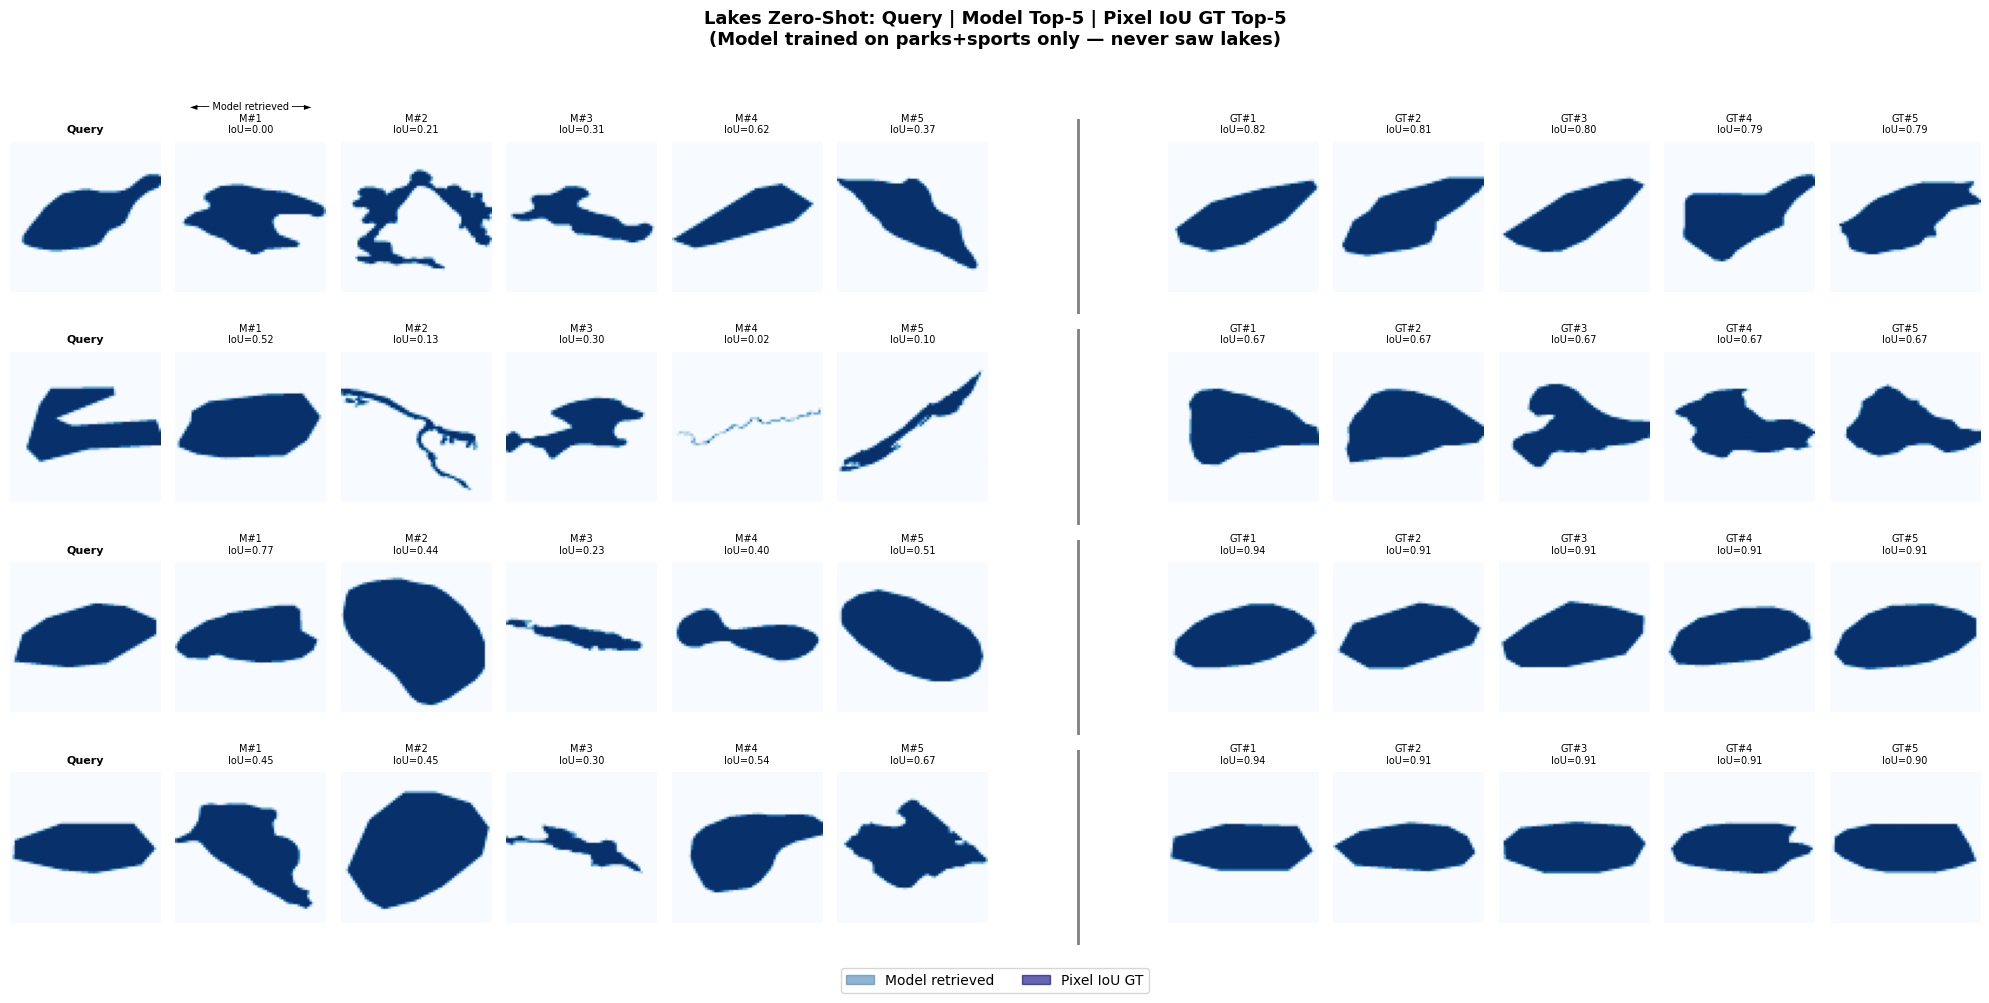

Saved /tmp/lakes_zeroshot_visual.png


In [12]:
# ── Visual: query lake + model top-5 vs pixel IoU top-5 ──────────────────────
if run_eval:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    N_SAMPLES   = 4    # number of query lakes to show
    N_SHOW      = 5    # neighbors to show per query

    # Pick queries with decent coverage (not too empty, not too uniform)
    coverages = lakes_query_rasters.sum(axis=(1, 2))
    # Sample from the middle 50% of coverage values for diverse but visible lakes
    low, high = np.percentile(coverages, 25), np.percentile(coverages, 75)
    candidates = np.where((coverages >= low) & (coverages <= high))[0]
    sample_qidx = np.random.choice(candidates, N_SAMPLES, replace=False)

    fig, axes = plt.subplots(
        N_SAMPLES, 1 + N_SHOW * 2 + 1,   # query | model×5 | divider | GT×5
        figsize=(20, N_SAMPLES * 2.5),
    )
    fig.suptitle(
        "Lakes Zero-Shot: Query | Model Top-5 | Pixel IoU GT Top-5\n"
        "(Model trained on parks+sports only — never saw lakes)",
        fontsize=13, fontweight='bold'
    )

    cmap = 'Blues'

    for row, qi in enumerate(sample_qidx):
        q_raster   = lakes_query_rasters[qi]
        m_ids      = [nbrs_l[qi][0][j] for j in range(N_SHOW)]
        g_ids      = gt_ids[qi, :N_SHOW].tolist()

        col = 0

        # ── Query ────────────────────────────────────────────────────────────
        ax = axes[row, col]
        ax.imshow(q_raster, cmap=cmap, vmin=0, vmax=1)
        ax.set_title("Query", fontsize=8, color='black', fontweight='bold')
        ax.axis('off')
        col += 1

        # ── Model top-5 ───────────────────────────────────────────────────────
        for rank, cid in enumerate(m_ids):
            ax = axes[row, col]
            ax.imshow(lakes_corpus_rasters[cid], cmap=cmap, vmin=0, vmax=1)
            # Compute IoU with query for this result
            inter = np.minimum(q_raster, lakes_corpus_rasters[cid]).sum()
            union = np.maximum(q_raster, lakes_corpus_rasters[cid]).sum()
            iou   = inter / max(union, 1e-6)
            ax.set_title(f"M#{rank+1}\nIoU={iou:.2f}", fontsize=7)
            ax.axis('off')
            col += 1

        # ── Divider ───────────────────────────────────────────────────────────
        ax = axes[row, col]
        ax.axvline(x=0.5, color='gray', linewidth=2)
        ax.set_xlim(0, 1); ax.axis('off')
        col += 1

        # ── Pixel IoU GT top-5 ────────────────────────────────────────────────
        for rank, cid in enumerate(g_ids):
            ax = axes[row, col]
            ax.imshow(lakes_corpus_rasters[cid], cmap=cmap, vmin=0, vmax=1)
            iou = gt_scores[qi, rank]
            ax.set_title(f"GT#{rank+1}\nIoU={iou:.2f}", fontsize=7)
            ax.axis('off')
            col += 1

    # Column header labels
    axes[0, 0].set_title("Query", fontsize=8, fontweight='bold', color='black')
    axes[0, 1].set_title(f"◄── Model retrieved ──►\nM#1\nIoU={0:.2f}",
                         fontsize=7)  # will be overwritten per row

    # Legend
    model_patch = mpatches.Patch(color='steelblue', alpha=0.6, label='Model retrieved')
    gt_patch    = mpatches.Patch(color='navy',      alpha=0.6, label='Pixel IoU GT')
    fig.legend(handles=[model_patch, gt_patch], loc='lower center',
               ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("/tmp/lakes_zeroshot_visual.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved /tmp/lakes_zeroshot_visual.png")

In [13]:
# ── Save results ─────────────────────────────────────────────────────────────
if run_eval:
    payload = {
        "results": results,
        "_meta": {
            "model": "RasterCNNEncoder",
            "grid_size": GRID_SIZE,
            "out_dim": OUT_DIM,
            "train_data": "parks_50k + sports_50k",
            "loss": "InfoNCE_intersection",
            "raster": "centered + global_scale + 4x_supersampling",
            "parks_rerank": "WJ_quadtree",
            "sports_rerank": "pixel_IoU_quadtree_free",
            "zeroshot": "lakes_20k",
            "time": __import__('time').strftime("%Y-%m-%d %H:%M:%S"),
        }
    }
    with open(out_path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved {out_path}")

    print("\n--- Reference: nb 16 parks-only MLP (quadtree, 10k) ---")
    print("  Stage-1 R@10: 0.673 | K=500 rerank R@10: 0.996")

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()

Saved /tmp/results_cnn_raster.pkl

--- Reference: nb 16 parks-only MLP (quadtree, 10k) ---
  Stage-1 R@10: 0.673 | K=500 rerank R@10: 0.996
